In [76]:
import numpy as np
import pandas as pd
import random

In [77]:
df=pd.read_csv('/content/student_clustering.csv')
df.head()
x=df.iloc[:,:]

In [80]:
class KMeans():
  def __init__(self,n_clusters,n_iter):
    self.n_clusters=n_clusters
    self.iter=n_iter
    self.centroid=None

  def fit_predict(self,X):
    random_idx=random.sample(range(0,X.shape[0]),self.n_clusters)
    self.centroid=X[random_idx]

    for i in range(self.iter):
      clustered_grp=self.create_clusters(X)
      old_centroid=self.centroid
      self.centroid=self.move_centroid(clustered_grp,X)
      if (self.centroid==old_centroid).all():
        break
    return clustered_grp

  def move_centroid(self,clustered_grp,X):
    new_centroid=[]
    unq=np.unique(clustered_grp)

    for types in unq:
      new_centroid.append(X[clustered_grp == types].mean(axis=0))
    return np.array(new_centroid)

  def create_clusters(self,X):
    clusters=[]
    distance=[]
    for row in range(X.shape[0]):
      for idx in self.centroid:
        distance.append(np.sqrt(np.dot(X[row]-idx,X[row]-idx)))
      minimum=min(distance)
      idx=distance.index(minimum)
      clusters.append(idx)
      distance.clear()
    return np.array(clusters)

In [81]:
km=KMeans(2,10)
km.fit_predict(x.values)

array([0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1])

In [86]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,10):
  km=KMeans(n_clusters=i)
  km.fit_predict(x)
  wcss.append(km.inertia_)

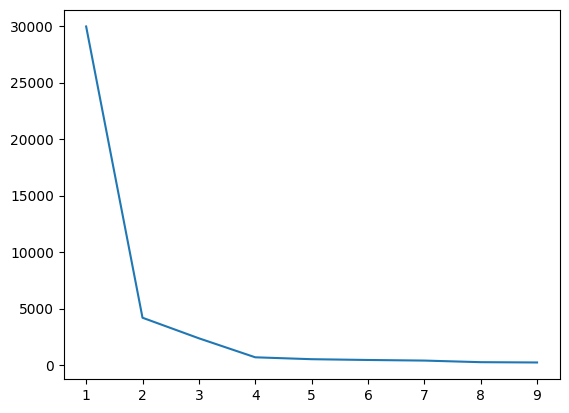

In [90]:
import matplotlib.pyplot as plt
plt.plot(range(1,10),wcss)

In [ ]:
+